# Les fonctions

Ce notebook couvre en profondeur les **fonctions** en Python : comment créer une fonction, comment exploiter le résultat, maîtriser les paramètres et les pièges à éviter.

Vous trouverez des **exemples exécutables** ainsi que des **exercices**.

**Objectifs :**
- Comprendre le rôle des fonctions pour structurer un programme.
- Savoir définir, appeler et documenter des fonctions claires.
- Maîtriser les paramètres (positionnels, nommés, par défaut, keyword-only, *args, **kwargs).
- Distinguer valeur de retour vs affichage (print), et fonction pure vs effets de bord.
- Comprendre la portée (LEGB), `global` et `nonlocal`.
- Appliquer `pass` et le principe DRY.

## 1. Définition

Une **fonction** est un **bloc de code nommé** qui exécute une tâche bien précise.
Elle peut recevoir des **paramètres** (données en entrée) et **retourner** une ou plusieurs **valeurs** (résultats en sortie).

C'est un **élément fondamental** de la programmation structurée : elle permet de découper un programme complexe en **petites unités autonomes** et réutilisables.

**Pourquoi utiliser des fonctions ?**

* Pour **nommer une intention** : le code devient lisible comme une phrase ; Par exemple `calculer_tva(prix)` exprime directement ce qu'il fait.
* Pour **éviter la répétition** (principe [*DRY* – *Don’t Repeat Yourself*](https://medium.com/@virtualik/dry-dont-repeat-yourself-principle-in-python-a-practical-guide-06290ebda0cf)) : on écrit une logique une seule fois et on la réutilise.
* Pour **isoler la complexité** : chaque fonction s'occupe d'un problème précis, ce qui facilite la lecture et la maintenance.
* Pour **tester plus facilement** : chaque fonction peut être vérifiée indépendamment du reste du programme.
* Pour **organiser le code** : elles favorisent la clarté, la modularité et la collaboration dans un projet.

En résumé, une fonction est à un programme ce qu’une "recette" est à un plat :
elle décrit **comment obtenir un résultat**, à partir d'**ingrédients** (les paramètres), selon des **étapes** (les instructions), pour produire un **résultat final** (la valeur retournée).

## 2. Syntaxe minimale

La définition d'une fonction en Python suit une structure **simple et lisible**.
Chaque fonction commence par le mot-clé `def`, suivi de son **nom**, d'une liste de **paramètres entre parenthèses**, et d'un **bloc indenté** qui contient les instructions à exécuter.

```python
def nom_de_fonction(param1, param2):
    """Docstring (optionnel): que fait la fonction, paramètres, retour."""
    # corps
    return resultat  # optionnel
```

**Explications** :

* `def` indique à Python que l'on **déclare une fonction**.
* `nom_de_fonction` doit être **significatif** et respecter la **convention snake_case** (mots séparés par des underscores) ou éventuellement **camelCase**.
* Les **paramètres** représentent les **valeurs d'entrée** utilisées par la fonction. Ils sont optionnels. Une fonction peut **n'avoir aucun paramètre**.
* Le bloc indenté contient les **instructions** exécutées à chaque appel.
* `return` permet de **renvoyer une valeur** (sinon, la fonction renvoie `None` par défaut).
* La **docstring** (texte entre `"""`) sert à documenter le rôle, les paramètres et le résultat de la fonction.

**Exemple** : on nomme l'intention, on choisit des paramètres pertinents et on renvoie le résultat.

In [ ]:
def aire_rectangle(largeur, hauteur):
    """Calcule l'aire d'un rectangle en unités carrées."""
    aire = largeur * hauteur
    return aire

resultat = aire_rectangle(4, 7)
print(f"L'aire du rectangle est {resultat}")

L'aire du rectangle est 28


## 3. Affichage (`print`) vs valeur de retour (`return`)

En Python, il est essentiel de distinguer **ce que l'on affiche** de **ce que l'on retourne**.

* `print` **affiche** une information à l'écran (dans la console) pour un humain.
  C’est un **effet de bord** : cela n'a aucune utilité dans un calcul, mais permet de vérifier visuellement le comportement du programme.
  Exemple : afficher une phrase, un résultat intermédiaire, un message d'erreur...

* `return` **renvoie** une valeur au programme.
  C'est cette valeur qui pourra être **réutilisée** par une autre fonction, une opération, ou stockée dans une variable.
  Une fois qu'un `return` est exécuté, **la fonction s'arrête immédiatement**.

💡 **À retenir :**

* `print` → pour **informer l'utilisateur**.
* `return` → pour **faire circuler des données** dans le programme.
* Si aucune instruction `return` n'est présente, la fonction **renvoie implicitement `None`**.

🧭 **Bonne pratique :**
Retourner (`return`) dans la logique du programme ; imprimer (`print`) seulement pour illustrer ou déboguer.

**Synthèse :**

| Objectif               | Mot-clé   | Effet            | Utilisation typique           |
| ---------------------- | --------- | ---------------- | ----------------------------- |
| Informer l'utilisateur | `print()` | Effet de bord    | Messages, débogage            |
| Fournir un résultat    | `return`  | Valeur de retour | Calculs, traitements, chaînes |

In [ ]:
## Exemple 1 : Avec "print"
def dire_bonjour(nom):
    print("Bonjour", nom)  # affichage, pas de valeur de retour

r = dire_bonjour("Ada")
print("Valeur de retour de dire_bonjour:", r)  # None

print("\n") # Saut de ligne, pour séparer les deux blocs dans la console

## Exemple 2 : Avec "return"
def construire_message(nom):
    if nom == "Nicolas":
      return "Hello Boss !"

    return f"Bonjour {nom}"  # la valeur est renvoyée, non affichée

message = construire_message("Nicolas")  # la fonction renvoie la chaîne
print("Valeur de retour de construire_message:", message)  # affichage séparé

Bonjour Ada
Valeur de retour de dire_bonjour: None


Valeur de retour de construire_message: Hello Boss !


## 4. Paramètres : positionnels, nommés et par défaut

Les **paramètres** permettent à une fonction de recevoir des **valeurs extérieures** et de travailler avec ces données.

En Python, il existe plusieurs manières de passer des arguments à une fonction. Comprendre cette distinction est essentiel pour écrire un code **clair**, **prévisible** et **réutilisable**.


#### Paramètres positionnels
Les arguments sont transmis **dans l’ordre**.  
Le premier argument remplit le premier paramètre, le second remplit le deuxième, etc.

> ⚠️ Si l'ordre est inversé, le résultat peut être incorrect ou provoquer une erreur.

In [ ]:
def presentation(nom, age):
    print(f"{nom} a {age} ans.")

presentation("Alice", 25)     # ✅ Correct
presentation(25, "Alice")     # ⚠️ Mauvais ordre : incohérent

Alice a 25 ans.
25 a Alice ans.


#### Paramètres nommés (`param=valeur`)

Les paramètres sont identifiés **explicitement** par leur nom lors de l'appel.

Cela améliore la **lisibilité** et **évite les erreurs d’ordre** :

> 💡 En combinant positionnels et nommés, les **positionnels doivent toujours précéder** les nommés.

In [ ]:
def deplacer(x, y):
    print(f"Déplacement vers x={x}, y={y}")

deplacer(y=1, x=2)  # l'ordre n'a plus d'importance

#### Paramètres avec valeurs par défaut

Un paramètre peut avoir une **valeur par défaut**, utilisée si l'argument correspondant n'est pas fourni lors de l’appel.

Cela rend certains paramètres **optionnels** et documente le comportement par défaut de la fonction.

In [ ]:
def prix_ttc(ht, taux=0.2):
    return ht * (1 + taux)

print(prix_ttc(100))              # 120.0 (taux par défaut 20 %)
print(prix_ttc(100, taux=0.055))  # 105.5 (taux réduit)

120.0
105.5


#### Bonnes pratiques

* Donnez toujours une **valeur par défaut claire et cohérente** avec le contexte métier.
* Utilisez des **arguments nommés** lorsque la fonction a beaucoup de paramètres.
* Vérifiez que l'ordre des paramètres reste **logique** (ex : `montant`, puis `taux`).
* Évitez les **paramètres mutables** (comme une liste ou un dictionnaire) comme valeur par défaut.


#### Exemple combiné

Dans cet exemple :

* `prenom` est **obligatoire** (aucune valeur par défaut).
* `civilite` est **optionnel** (valeur par défaut `"M."`).
* L'appel peut être fait de manière **positionnelle** ou **nommée**, selon le besoin.

In [ ]:
def saluer(prenom, civilite="M."):
    print(f"Bonjour {civilite} {prenom}")

saluer("Dupont")                           # Bonjour M. Dupont
saluer("Lovelace", civilite="Mme")  # Bonjour Mme Lovelace

Bonjour M. Dupont
Bonjour Mme Lovelace


## 5. Paramètres avancés : `*args`, `**kwargs`, keyword-only

Les fonctions peuvent accepter un **nombre variable d'arguments**, ou des **arguments nommés flexibles**.  
Ces mécanismes rendent les fonctions **plus générales** et **plus réutilisables**.

#### `*args` : nombre variable d'arguments positionnels  
Le paramètre précédé d'une étoile (`*`) capture **tous les arguments positionnels supplémentaires** sous forme de **tuple**.  
C'est utile lorsqu'on ne connaît pas à l'avance le nombre exact de valeurs à traiter.

> 💡 Bonne pratique : on nomme souvent ce paramètre `*args`, mais n'importe quel nom précédé de `*` fonctionne.

In [ ]:
def somme(*args):
    total = 0
    for n in args:
        total = total + n
    return total

print(somme(1, 2, 3))       # 6
print(somme(10, -5, 4, 1))  # 10

6
10


In [ ]:
def addition(a, b):
  return a + b

def multiplication (a, b, c):
  return a * b * c

def executer_avec_logs(fonction, *args):
  print("Démarrage de la fonction")
  result = fonction(*args)
  print(f"Fin de la fonction, resultat={result}")
  return result

result = executer_avec_logs(addition, 2, 4)
result = executer_avec_logs(multiplication, 2, 3, 5)





Démarrage de la fonction
Fin de la fonction, resultat=6
Démarrage de la fonction
Fin de la fonction, resultat=30


#### `**kwargs` : arguments nommés additionnels

Le paramètre précédé de deux étoiles (`**`) capture **tous les arguments nommés supplémentaires** sous forme de **dictionnaire**.
Chaque clé correspond au nom du paramètre, et chaque valeur correspond à l'argument passé.

> ✅ Très pratique pour écrire des fonctions configurables sans devoir définir chaque option à l'avance.

In [ ]:
def afficher_infos(**kwargs):
    print(kwargs)
    for cle, valeur in kwargs.items():
        print(cle, "→", valeur)

afficher_infos(nom="Ada", pays="UK", domaine="Math/CS", url="https://...", prenom="Nicolas")

{'nom': 'Ada', 'pays': 'UK', 'domaine': 'Math/CS', 'url': 'https://...', 'prenom': 'Nicolas'}
nom → Ada
pays → UK
domaine → Math/CS
url → https://...
prenom → Nicolas


#### Paramètres *keyword-only*

Les paramètres définis **après un `*`** doivent obligatoirement être passés **avec un nom explicite**.
Cela renforce la **clarté** et évite les erreurs dues à l'ordre des arguments.

Dans l'exemple ci-dessous :

* `hote` est **positionnel** (obligatoire et premier).
* `port` et `ssl` sont **keyword-only**, donc doivent être précisés comme `port=...` et `ssl=...`.
* Cela rend l'appel de la fonction plus **expressif** et **auto-documenté**.

In [ ]:
def config_connexion(hote, *args, port=5432, ssl=False):
  print("args", args)
  print("Hote: ", hote)
  print("Port: ", port)
  print("SSL: ", ssl)

  return {"hote": hote, "port": port, "ssl": ssl}

print(config_connexion("db.exemple.com", 3306, True))
print(config_connexion("db.exemple.com", port=3306, ssl=True))

args (3306, True)
Hote:  db.exemple.com
Port:  5432
SSL:  False
{'hote': 'db.exemple.com', 'port': 5432, 'ssl': False}
args ()
Hote:  db.exemple.com
Port:  3306
SSL:  True
{'hote': 'db.exemple.com', 'port': 3306, 'ssl': True}


## 6. Retourner plusieurs valeurs (tuple)

Une fonction peut **retourner plusieurs valeurs à la fois** en Python.  
Plutôt que de renvoyer un seul résultat, on peut renvoyer **plusieurs informations groupées dans un tuple**.

Cela permet à une fonction de **communiquer plusieurs résultats** sans recourir à des variables globales ni à des effets de bord.


In [ ]:
def division_euclidienne(a, b):
    q = a // b
    r = a % b
    return (q, r)

print(type(division_euclidienne(7,1))) # Tuple
quotient, reste = division_euclidienne(17, 5)
print(quotient, reste)  # 3 2

<class 'tuple'>
3 2


**Explications :**

* `return q, r` renvoie un **tuple** implicite contenant deux valeurs.
* L’appel `division_euclidienne(17, 5)` retourne donc `(3, 2)`.
* En Python, on peut **déballer** ce tuple dans deux variables distinctes :
  `quotient, reste = ...`
* Cette approche rend le code **plus lisible** et **plus clair** qu'un retour sous forme de liste ou de dictionnaire si l’ordre des valeurs est bien défini.

**💡 Astuce :**

Il est possible de **retourner n’importe quel nombre de valeurs**, ou même des structures plus complexes (liste, dictionnaire, tuple imbriqué).

Exemple :

In [ ]:
def analyse_texte(texte):
    nb_caracteres = len(texte)
    nb_mots = len(texte.split())
    return (nb_caracteres, nb_mots)

resultat = analyse_texte("Python est un langage clair et puissant.")
longueur, mots = resultat
print(f"Caractères : {longueur}, Mots : {mots}")

Caractères : 40, Mots : 7


> Résultat :
>
> ```
> Caractères : 40, Mots : 7
> ```

**✅ Bonnes pratiques :**

* Donnez des **noms explicites** aux variables que vous déballez (`x_min, x_max = plage(...)` plutôt que `a, b = plage(...)`).
* Réservez les tuples à des retours **simples et cohérents** : si la structure devient complexe, préférez un **dictionnaire** ou une **classe**.

## 7. Docstrings et annotations de type (lisibilité)

Les **docstrings** et les **annotations de type** sont deux outils essentiels pour rendre le code **plus clair et plus professionnel**.

- Les **docstrings** décrivent ce que fait la fonction, les paramètres qu'elle attend et la valeur qu'elle retourne.  
  Elles sont placées juste après la ligne `def`, entre guillemets triples `"""..."""`.  
  Elles peuvent être lues avec `help(nom_de_fonction)` ou `nom_de_fonction.__doc__`.

- Les **annotations de type** indiquent le type attendu des paramètres et du résultat.  
  Elles ne bloquent pas l'exécution, mais servent à **documenter le code** et à **aider les outils de vérification** (IDE, analyseurs statiques, etc.).

In [ ]:
def moyenne(notes: list[float]) -> float:
    """
    Calcule la moyenne d'une liste de notes (float).
    Retourne 0.0 si la liste est vide.
    """
    if not notes:
        return 0.0
    return sum(notes) / len(notes)

print(moyenne([12.0, 14.5, 9.0]))

11.833333333333334


**Explications :**

* `notes: list[float]` indique que le paramètre `notes` doit être une **liste de nombres à virgule flottante**.
* `-> float` précise que la fonction retourne une **valeur flottante**.
* La docstring décrit **l'objectif**, **le comportement**, et **les cas particuliers**.

Les IDE comme VSCode sont en mesure d'interpréter ces notations pour vous fournir de l'aide au survol d'une méthode :

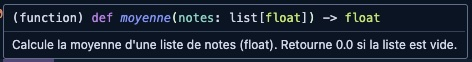

**✅ Bonnes pratiques :**

* Écrire la docstring **immédiatement après** la déclaration de la fonction.
* Utiliser un style clair et concis : une phrase brève au présent de l'indicatif.
* Mentionner les cas particuliers (par exemple, liste vide, division par zéro, etc.).
* Employer les annotations pour **clarifier l'intention**, pas pour imposer une contrainte.

## 8. Fonctions pures vs effets de bord (mutabilité)

En programmation, on distingue deux grandes catégories de fonctions selon leur comportement sur les données.

- **Pure** : produit toujours la **même sortie pour les mêmes entrées** et **n'a aucun effet externe**.  
  Elle ne dépend que de ses paramètres et ne modifie pas d'autres variables.  
  Ce type de fonction est plus **prévisible**, **testable** et **réutilisable**.

- **Avec effets de bord** : modifie un **état extérieur** à la fonction (variable globale, fichier, affichage, base de données, etc.).  
  Ce type de fonction est parfois nécessaire, mais rend le code plus **difficile à déboguer** et à maintenir.

> ⚠️ En Python, il faut être particulièrement attentif aux **objets mutables** (listes, dictionnaires, ensembles).  
> Une fonction peut les modifier sans qu'on s'en rende compte.


#### Exemple d'une fonction avec effet de bord :

Ici, la fonction ne renvoie rien, mais **modifie directement la liste reçue**.
Ce comportement peut surprendre si l'on s'attendait à ce que la liste d'origine reste inchangée.


In [ ]:
def ajouter_exclamation_inplace(liste):
    for i, s in enumerate(liste):
        liste[i] = s + "!"  # modifie la liste d'origine

mots = ["bon", "jour"]
ajouter_exclamation_inplace(mots)
print(mots)  # ['bon!', 'jour!']

['bon!', 'jour!']


#### Exemple d'une fonction pure :

Cette version est **pure** : elle **crée une nouvelle liste** et ne touche pas aux données initiales.
Les entrées ne changent jamais, et le résultat dépend uniquement des paramètres.


In [ ]:
def avec_exclamation(liste):
    nouvelle_liste = []
    for mot in liste:
        nouvelle_liste.append(mot + "!")
    return nouvelle_liste

mots = ["bon", "jour"]
print(avec_exclamation(mots))  # ['bon!', 'jour!']
print(mots)                    # ['bon', 'jour']

['bon!', 'jour!']
['bon', 'jour']


#### 💡 Bonnes pratiques :

* Privilégier les **fonctions pures** dès que possible (plus sûres et faciles à tester).
* Documenter clairement si une fonction **modifie** ses arguments.
* En cas de doute, **copier** la donnée mutable à l'intérieur de la fonction (`liste.copy()` ou `dict.copy()`).
* Utiliser les **retours de fonction** (`return`) plutôt que la modification directe des objets.

## 9. Portée (LEGB), global et nonlocal

En Python, chaque variable a une **portée** (ou *scope*) : c'est la zone du programme dans laquelle elle est accessible.

L'ordre de recherche d'une variable suit le principe **LEGB** :
**L**ocal → **E**nclosing → **G**lobal → **B**uiltins.

- **Local** : variable définie à l'intérieur d'une fonction.  
- **Enclosing** : variable dans une fonction englobante (fonction imbriquée).  
- **Global** : variable définie au niveau du module (hors fonction).  
- **Builtins** : variables intégrées à Python (`len`, `sum`, etc.).

#### Mots-clés utiles :
- `global` : permet de modifier une **variable globale** depuis une fonction (à éviter sauf cas particulier).  
- `nonlocal` : permet de modifier une variable de la **fonction englobante** (non globale).

Dans l'exemple ci-dessous :

* `x = 5` dans `f()` est une variable **locale**.
* `global x` dans `g()` indique qu'on modifie la variable `x` définie à l'extérieur de la fonction.
* L'utilisation de `global` doit rester **exceptionnelle**, car elle rend le code moins prévisible.

In [ ]:
x = 10  # globale

def f():
    x = 5  # locale
    print("locale x =", x)

def g():
    global x
    x = 99  # modifie la variable globale
    print(x)

f()
print("globale x =", x)
g()
print("globale x après g() =", x)

locale x = 5
globale x = 10
99
globale x après g() = 99


#### Exemple avec `nonlocal`

`nonlocal` permet d'accéder à une variable définie dans la **fonction englobante** (non dans le module).

Dans l'exemple ci-dessous :

* `compteur` appartient à la fonction englobante `generateur_compteur`.
* Le mot-clé `nonlocal` permet à la fonction `incrementer()` de **modifier** cette variable à chaque appel.
* Ce mécanisme est souvent utilisé pour créer des **fermetures (closures)** : des fonctions qui conservent un état interne.

In [ ]:
def generateur_compteur():
    compteur = 0

    def incrementer():
        nonlocal compteur
        compteur += 1
        return compteur

    def decrementer():
        nonlocal compteur
        compteur -= 1
        return compteur

    return incrementer, decrementer

inc, dec = generateur_compteur()
print(inc())  # 1
print(inc())  # 2
print(dec()) # 1
print(inc()) # 2

1
2
1
2


#### 💡 À retenir :

* Toujours **préférer les variables locales** à l'intérieur des fonctions.
* Éviter `global` sauf pour des constantes ou des configurations partagées.
* `nonlocal` est utile dans les fonctions imbriquées pour gérer un état sans passer par des variables globales.

## 10. Le mot-clé pass

`pass` est une **instruction vide** : elle ne fait absolument rien lorsqu'elle est exécutée.  
On l'utilise quand la syntaxe du langage **exige un bloc d'instructions**, mais que l'on n'a **rien à écrire pour le moment**.

C'est une sorte de **bouchon temporaire** : cela permet de garder le code valide tout en indiquant qu'il faudra compléter la partie plus tard.

**Exemples d'utilisation courante :**

- Lorsqu'on écrit une **fonction en construction** (non encore implémentée).  
- Dans une **branche conditionnelle** où aucune action n'est encore définie.  
- Dans une **classe vide** servant de structure de base.

Exemples :

In [ ]:
# Exemple 1 : Utilisation de "pass" pour garder une branche vide
x = 10
if x > 0:
    pass  # Rien à faire si x est positif
else:
    print("x négatif")

# Exemple 2 : Utilisation de "pass" en guise de TODO
def a_faire_plus_tard():
  pass  # TODO : implémenter plus tard

print("Retour de la fonction vide :", a_faire_plus_tard())  # None

Retour de la fonction vide : None


#### 💡 À retenir :

* `pass` n'exécute aucune instruction et ne retourne rien.
* Il permet de **réserver une place dans le code** pour une logique à venir.
* Sans `pass`, un bloc vide (`if`, `def`, `class`) provoquerait une erreur de syntaxe (`IndentationError` ou `SyntaxError`).

## 11. Principe DRY (factoriser la logique)

Le principe **DRY** (*Don't Repeat Yourself*) consiste à **ne pas répéter** plusieurs fois la même logique dans un programme.  
L'idée est d'**écrire le code une seule fois**, dans une fonction, puis de **le réutiliser partout**.  

Cela permet d'obtenir :
- un code **plus clair** et **plus lisible**,  
- moins de **risques d'erreurs** (une seule correction à faire),  
- une **maintenance facilitée**.

#### Exemple sans DRY :

In [ ]:
tva = 0.2

p1, p2, p3 = 80, 120, 50

p1_ttc = p1 * (1 + tva)
p2_ttc = p2 * (1 + tva)
p3_ttc = p3 * (1 + tva)

print(p1_ttc, p2_ttc, p3_ttc)

96.0 144.0 60.0


Ici, le calcul `ht * (1 + tva)` est répété **trois fois** : si la formule change, il faudra la modifier partout.

#### Version améliorée avec DRY :

In [3]:
def ttc(ht, taux = 0.2):
    return ht * (1 + taux)

print(ttc(80), ttc(120), ttc(50))

96.0 144.0 60.0


La logique du calcul est **centralisée** dans la fonction `ttc`.
Si la formule change, il suffit de la corriger **à un seul endroit**.


#### 💡 À retenir :

* DRY signifie : *ne pas dupliquer inutilement le code*.
* Une fonction doit être utilisée pour **factoriser** une logique répétitive.
* Cela améliore la **fiabilité** et la **maintenabilité** du programme.

## 12. Bonnes pratiques

### 12.1. Noms explicites + docstring

In [ ]:
def aire_cercle(rayon: float) -> float:
    """
    Calcule l'aire d'un cercle (π * r²).
    """
    return 3.14 * (rayon ** 2)

print(round(aire_cercle(3), 2))

28.26


### 12.2. Éviter les paramètres mutables par défaut

In [ ]:
def ajouter_mauvais(element, collection=[]):
    collection.append(element)
    return collection

print(ajouter_mauvais("a"))
print(ajouter_mauvais("b")) # surprise: partagé entre appels

['a']
['a', 'b']


In [ ]:
def ajouter_bon(element, collection=None):
    if collection is None:
        collection = []
    collection.append(element)
    return collection

print(ajouter_bon("a"))
print(ajouter_bon("b"))

['a']
['b']


### 12.3. Préférer retourner une valeur plutôt que d'imprimer

In [ ]:
def somme(a, b):
    return a + b

print("Résultat:", somme(2, 3))

### 12.4. Guard clauses (retours précoces)

In [ ]:
import math

def racine(x):
    if x < 0:
      return None

    return math.sqrt(x)

print(racine(9), racine(-1))

3.0 None


### 12.5. Paramètres keyword-only pour clarifier l'appel

In [ ]:
def creer_utilisateur(nom, *, prenom, actif=True):
    return {"nom": nom, "prenom": prenom, "actif": actif}

print(creer_utilisateur("Durand", prenom="Sophie"))
print(creer_utilisateur("Martin", prenom="Léo", actif=False))

{'nom': 'Durand', 'prenom': 'Sophie', 'actif': True}
{'nom': 'Martin', 'prenom': 'Léo', 'actif': False}


### 12.6. Tests rapides avec assert

In [1]:
def max2(a, b):
    return a if a >= b else b

assert max2(5, 2) == 5
assert max2(-1, -3) == -1
print("Asserts OK")

Asserts OK


## 13. Mise en pratique

### Exercice 1 : Calcul une réduction sur un prix

Écrire une fonction `prix_reduit` qui **calcule et retourne le prix après réduction** à partir d'un prix initial et d'un taux de réduction.

Par défaut, la réduction sera de `0.1` (soit 10 %).

Par exemple, la fonction `prix_reduit(100)` devra retourner `90.0` et la fonction `prix_reduit(200, 0.25)` devra retourner `150.0`

In [ ]:
# Zone de code...
def prix_reduit(prix, reduction=0.1): # N'oubliez pas d'ajouter les paramètres
  pass

print("Prix réduit =", prix_reduit(200, 0.25))

Prix réduit = None


### Exercice 2 : Normaliser des prénoms

Écrire une fonction `normaliser_noms(liste)` qui retourne une **nouvelle liste** contenant les prénoms correctement capitalisés. Par exemple, `normaliser_noms(["aDA", "bOB"])` doit retourner `["Ada", "Bob"]`.

⚠️ Attention à ne pas modifier la liste de base, mais à bien retourner une **copie**.

💡Une méthode permettant de retourner un mot normalisé existe dans les [méthodes exposés pour les strings](https://docs.python.org/3/library/stdtypes.html#text-and-binary-sequence-type-methods-summary).

In [ ]:
# Zone de code...
def normaliser_noms(liste):
  pass

print(normaliser_noms(["aDA", "bOB", "ALICE"]))

None


### Exercice 3 : Division sûre

Écrire une fonction `safe_div(a, b)` qui effectue une division sécurisée : elle retourne `a / b` lorsque `b` est différent de zéro, et `None` si `b` vaut zéro.

Par exemple, `safe_div(10, 2)` doit renvoyer `5.0`, tandis que `safe_div(10, 0)` doit renvoyer `None`.

💡  La fonction doit vérifier la valeur du dénominateur avant d’effectuer la division afin d'éviter toute erreur.

In [ ]:
# Zone de code...
def safe_div(a, b):
  pass

print(safe_div(10, 2))
print(safe_div(10, 0))

### Exercice 4 : Statistiques simples

Écrire une fonction `stats(nums)` qui retourne un **tuple** contenant le minimum, le maximum et la moyenne d'une liste de nombres.

Si la liste est vide, la fonction doit renvoyer `(None, None, 0.0)`.

Par exemple, `stats([5, 2, 9])` doit retourner `(2, 9, 5.333...)`.

In [2]:
# Zone de code...
def stats(nums):
  pass

print(stats([5,2,9]))

None


### Exercice 5 : Moyenne variable (`*args`)

Écrire une fonction `moyenne_var(*args)` qui calcule la moyenne des nombres passés en arguments.

Si aucun nombre n'est fourni, la fonction doit retourner `0.0`.

Par exemple, `moyenne_var()` doit renvoyer `0.0`, et `moyenne_var(1, 2, 3)` doit renvoyer `2.0`.

In [ ]:
# Zone de code...
def moyenne_var(*args):
  pass

print(moyenne_var())
print(moyenne_var(1, 2, 3))

### Exercice 6 : Formatage (keyword-only)

Écrire une fonction `format_personne(nom, *, prenom="", ville="")` qui construit une chaîne de caractères au format `"Prenom Nom (Ville)"`, en omettant les éléments vides.

Par exemple, `format_personne("Dupont", prenom="Ada", ville="Paris")` doit renvoyer `"Ada Dupont (Paris)"`, et `format_personne("Durand", prenom="Sophie")` doit renvoyer `"Sophie Durand"`.

Aucun espace inutile ne doit apparaître et les champs vides doivent être correctement ignorés.

In [ ]:
# Zone de code...
def format_personne(nom, *, prenom="", ville=""):
  pass

print(format_personne("Dupont", prenom="Ada", ville="Paris"))
print(format_personne("Durand", prenom="Sophie"))

<small>© Nicolas NUNGE - Version 1.0.0 - octobre 2025</small>